# Bank Customer Churn Prediction

In [129]:
#standard import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [130]:
# Sklearn
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold


In [131]:
#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [132]:
# Metrics and Utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")


In [133]:
#Display Settings
sns.set_theme(style="whitegrid", palette='muted',font_scale=1.05) #set the default value of seaborn graph
pd.set_option('display.max_columns',200) # only 200 value of data frame is shown 

## Loading the data

In [134]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")
print("shape:", df.shape)
df.head()

shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [135]:
display(df.info())
display(df.describe(include='all').T) # gives statistical summary of data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0


In [136]:
print("\nMissing Values per column:")
print(df.isnull().sum)



Missing Values per column:
<bound method DataFrame.sum of       customer_id  credit_score  country  gender    age  tenure  balance  \
0           False         False    False   False  False   False    False   
1           False         False    False   False  False   False    False   
2           False         False    False   False  False   False    False   
3           False         False    False   False  False   False    False   
4           False         False    False   False  False   False    False   
...           ...           ...      ...     ...    ...     ...      ...   
9995        False         False    False   False  False   False    False   
9996        False         False    False   False  False   False    False   
9997        False         False    False   False  False   False    False   
9998        False         False    False   False  False   False    False   
9999        False         False    False   False  False   False    False   

      products_number  credi

In [137]:
print("\nChurn Value Counts:")
print(df['churn'].value_counts(normalize=False))


print("\nChurn proportion:")
print(df['churn'].value_counts(normalize=True))


Churn Value Counts:
churn
0    7963
1    2037
Name: count, dtype: int64

Churn proportion:
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64


# EDA(Exploratory Data Analysis)

### Data Visualization

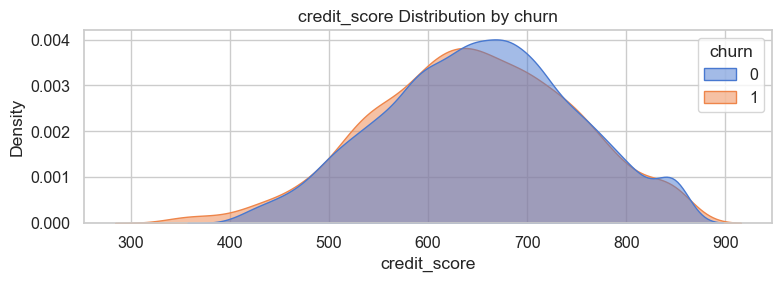

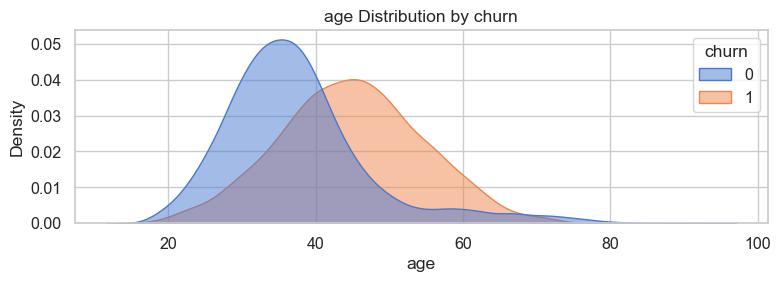

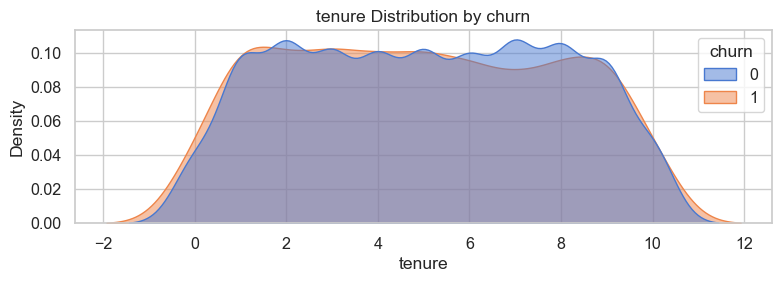

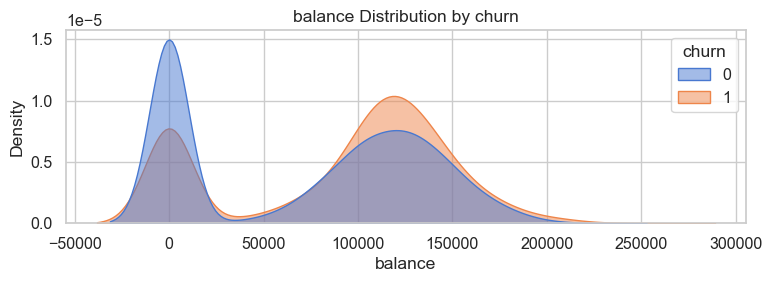

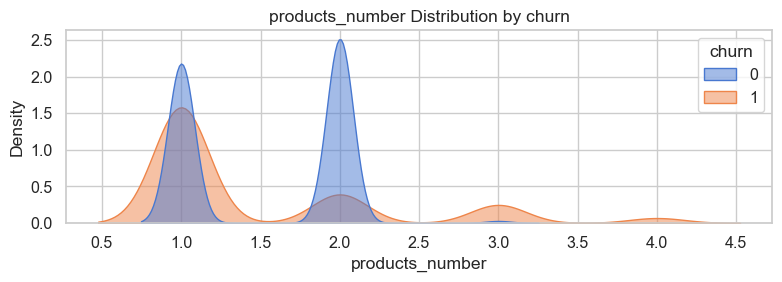

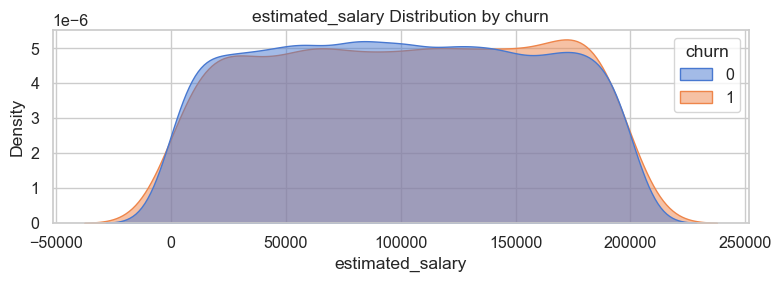

In [138]:
num_cols = ['credit_score','age','tenure','balance','products_number','estimated_salary']

for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{col} Distribution by churn')
    plt.tight_layout()
    plt.show()

### Pairplot (To quickley visualise the relation between numerical faetures)

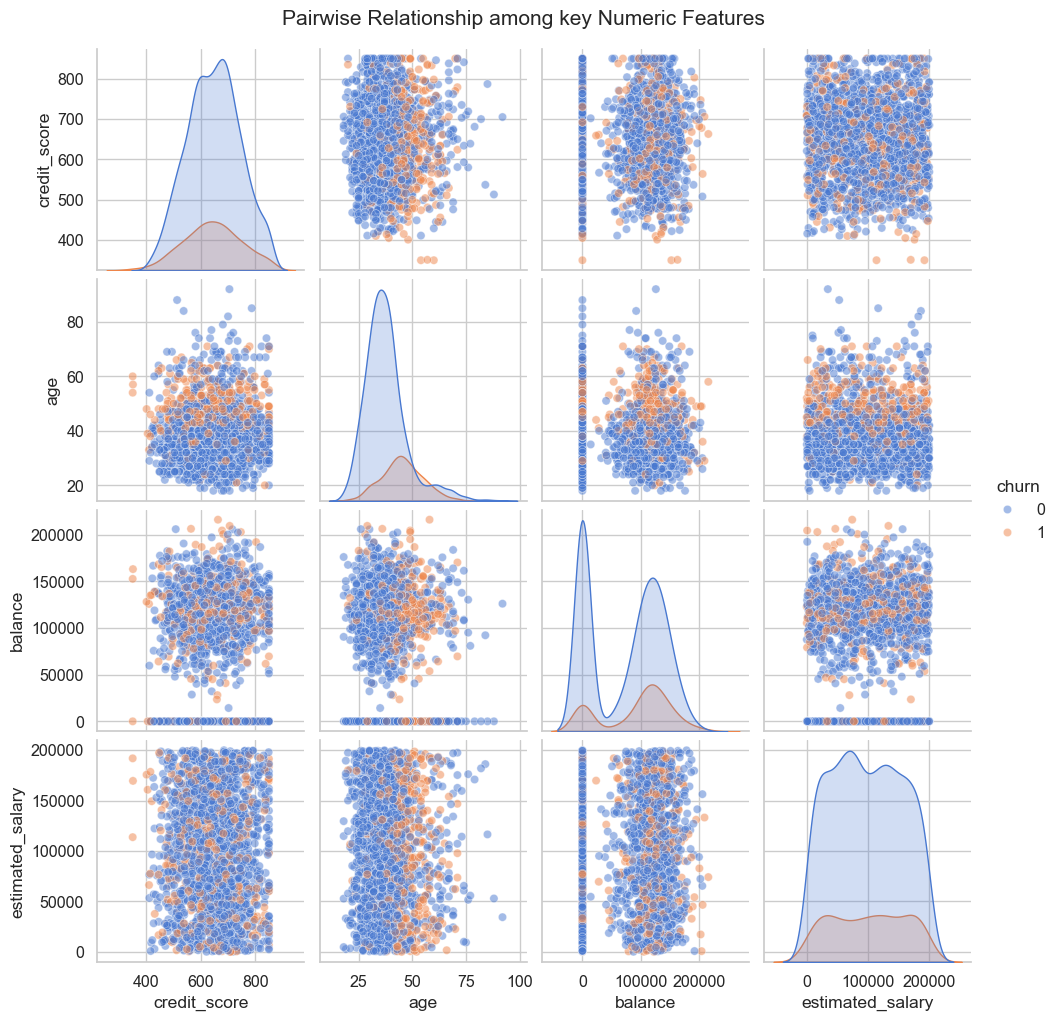

In [139]:
sns.pairplot(
    df.sample(frac=0.2, random_state=42),
    vars=['credit_score', 'age', 'balance', 'estimated_salary'],
    hue='churn',
    diag_kind="kde",
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pairwise Relationship among key Numeric Features', y=1.02)
plt.show()

### Violin Plot fro Age

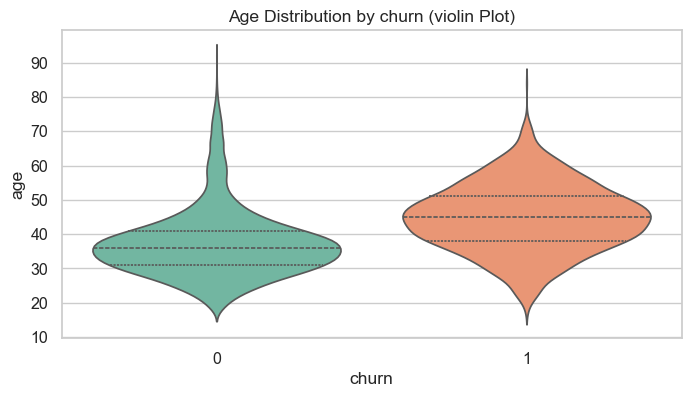

In [140]:
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='churn', y='age', inner='quart', palette='Set2')
plt.title('Age Distribution by churn (violin Plot)')
plt.show()

## Barplot (Tenure Distribution)

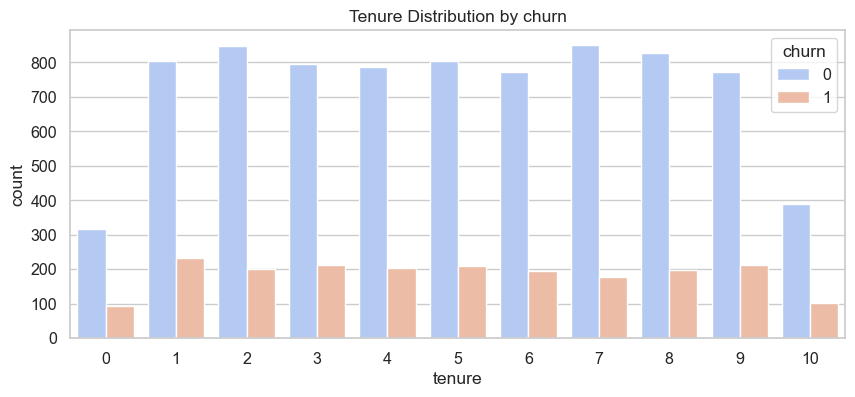

In [141]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='tenure', hue='churn', palette='coolwarm')
plt.title('Tenure Distribution by churn')
plt.show()

# Gender vs Churn Donut Chart

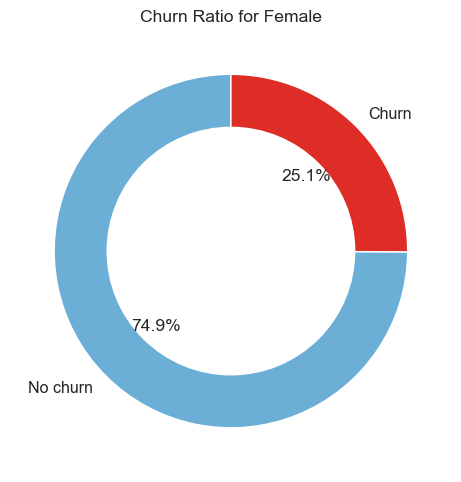

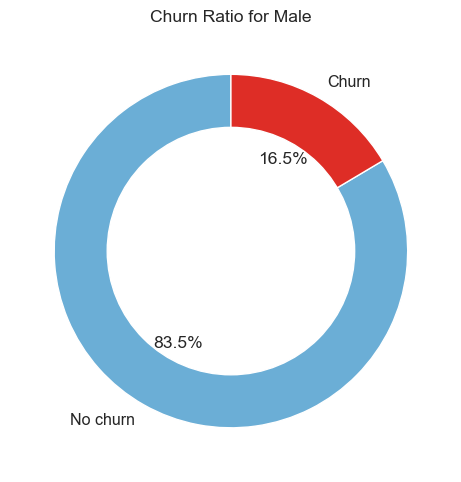

In [142]:
gender_count=df.groupby('gender')['churn'].value_counts(normalize=True).unstack().fillna(0)
for g in gender_count.index:
    plt.figure(figsize=(5,5))
    plt.pie(gender_count.loc[g],labels=['No churn','Churn'],autopct='%1.1f%%',startangle=90,colors=['#6baed6','#de2d26'])
    plt.gca().add_artist(plt.Circle((0,0),.7,fc='white'))
    plt.title(f'Churn Ratio for {g}');plt.tight_layout();plt.show()

## For catagorical features

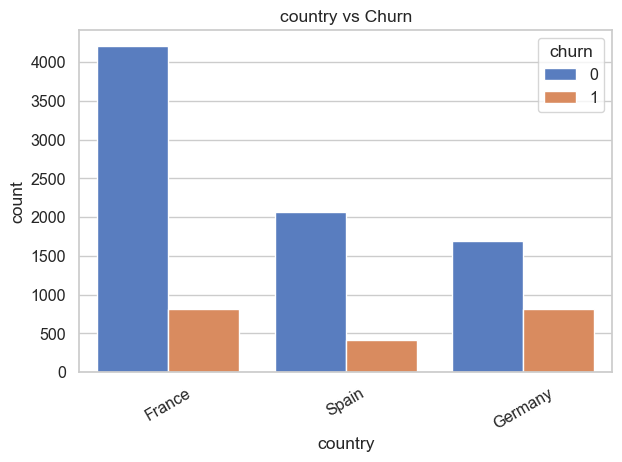

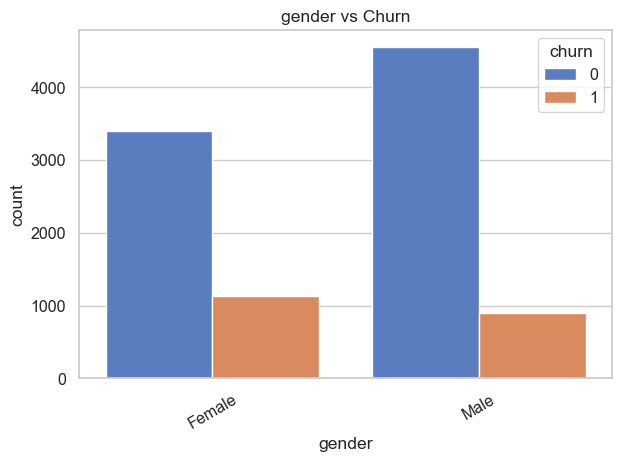

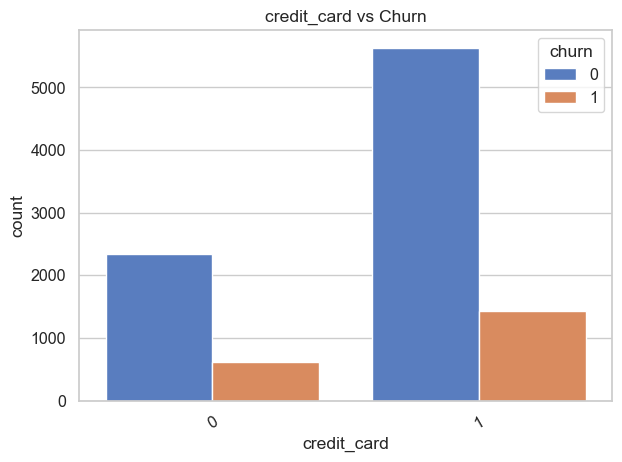

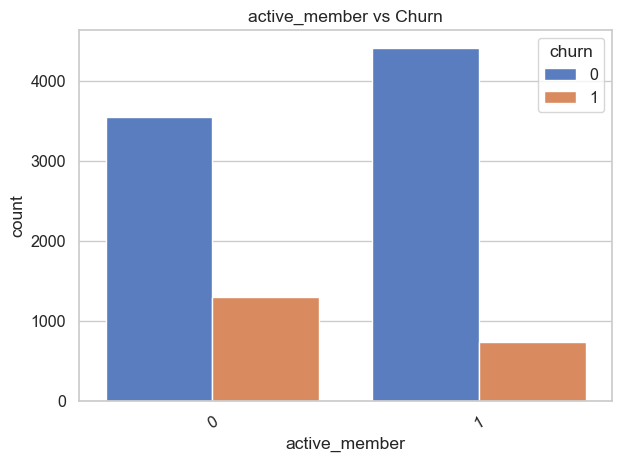

In [143]:
cat_cols = ['country', 'gender','credit_card','active_member']
for c in cat_cols:
    plt.Figure(figsize=(8,3))
    sns.countplot(data=df, x=c, hue='churn')
    plt.title(f'{c} vs Churn')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Heatmap Visualisation

In [144]:
corr = df.select_dtypes(include='number').corr()

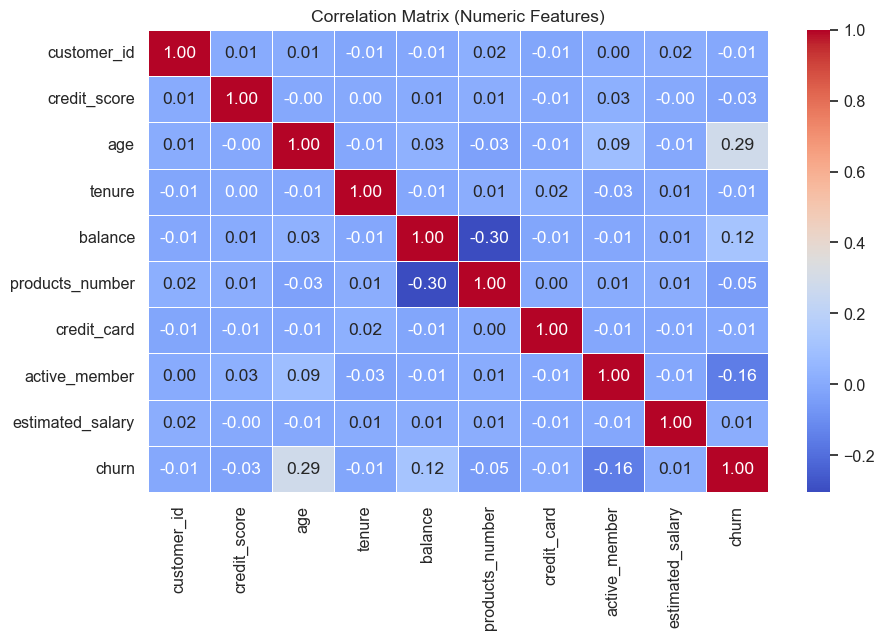

In [145]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix (Numeric Features)')
plt.show()

### Number Corelation Heatmap

In [146]:
numeric_data = df[num_cols] 
corr=numeric_data.corr()
corr.style.background_gradient(cmap='coolwarm')

,credit_score,age,tenure,balance,products_number,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


### Balance vs Product Scatter

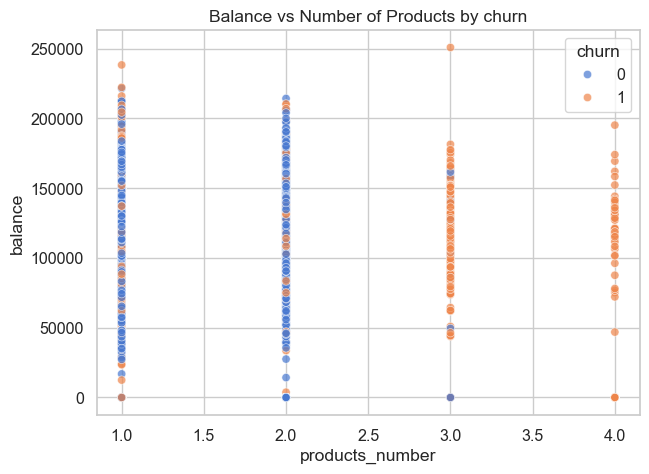

In [147]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='products_number', y='balance', hue='churn', alpha=0.7)
plt.title('Balance vs Number of Products by churn')
plt.show()

## Aggrigation Churn Rate per Number of products

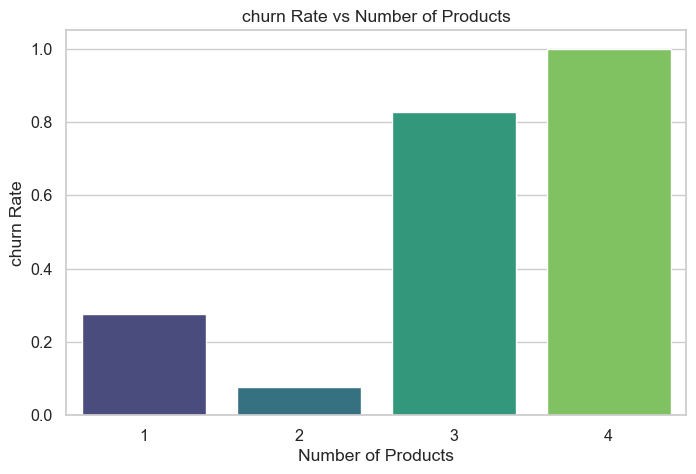

In [148]:
churn_rate = df.groupby('products_number')['churn'].mean().reset_index()

# plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate, x='products_number', y='churn', palette='viridis')
plt.xlabel('Number of Products')
plt.ylabel("churn Rate")
plt.title('churn Rate vs Number of Products')
plt.show()

# Feature Engineering
#### Creating new feature from existing ones. Features that can capture hidden realtionship in the data abd help the Model make the smarter prediction

In [149]:
# Balance per product (We divide the customers total balance by the numnber of products they hold. This helps the model accurately understand how effectively customer are distributing their money across products)
#! 1. salary of balance ratio - Estimated salary divided by the balance (The person with the very high slary but have 0 balance might behave differently because what is he quickley transfiring money quickley in other bank account)

#! 2. Categorise customer in different age groups like <25, 25 to 35, 35 to 45....(This capture behavioural pattern like young professional vs Mid career individuals vs retirees)

#! 3. Create tenure bucket - New customer with less than a year, customer with 3 to 5 years and loong tern ones with over 10 years

#! 4. Add a powerful binary feature- High balance with marks the customer balance is above top 25% of all balances. This helps the model Identify the premium customers



In [150]:
df_fe = df.copy()

# Balance per product
df_fe['balance_per_product'] = df_fe['balance'] / df_fe['products_number'].replace(0, np.nan)
df_fe['balance_per_product'].fillna(0, inplace=True)

# Salary to balance ratio
df_fe['salary_balance_ratio'] = df_fe['estimated_salary'] / df_fe['balance'].replace(0, np.nan)
df_fe['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].median(), inplace=True)

# Age Group
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df_fe['age_group'] = pd.cut(df_fe['age'], bins=bins, labels=labels)

# Tenure bucket
df_fe['tenure_bucket'] = pd.cut(
    df_fe['tenure'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['0', '1-2', '3-5', '6-10', '10+']
)

# Flag high balance
df_fe['high_balance'] = (df_fe['balance'] > df_fe['balance'].quantile(0.75)).astype(int)

# Quick checks
df_fe[['balance_per_product', 'salary_balance_ratio', 'age', 'age_group',
    'tenure', 'tenure_bucket', 'high_balance']].head()



,balance_per_product,salary_balance_ratio,age,age_group,tenure,tenure_bucket,high_balance
0,0.000000,0.839258,42,35-44,2,1-2,0
1,83807.860000,1.342864,41,35-44,1,1-2,0
2,53220.266667,0.713585,42,35-44,8,6-10,1
3,0.000000,0.839258,39,35-44,1,1-2,0
4,125510.820000,0.630098,43,35-44,2,1-2,0


# Data Preprocessing - Encoding and Scaling

In [151]:
# Define feature and target
target = 'churn'
drop_cols = ['customer_id']

features = [c for c in df_fe.columns if c not in [target] + drop_cols]

numeric_features = [
    'credit_score', 'age', 'tenure', 'balance',
    'products_number', 'estimated_salary',
    'balance_per_product', 'salary_balance_ratio'
]

categorical_features = [
    'country', 'gender', 'credit_card',
    'active_member', 'age_group', 'tenure_bucket',
    'high_balance'
]

df_fe[categorical_features] = df_fe[categorical_features].astype('object')

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']


## Train Test Split

In [152]:
X = df_fe[features]
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print('Train shape:',X_train.shape,'Test shape:', X_test.shape)
print('Train churn proportion:', y_train.mean(), 'Test churn proportion:', y_test.mean())

Train shape: (8000, 15) Test shape: (2000, 15)
Train churn proportion: 0.2055 Test churn proportion: 0.1965


## Train multiple model with a pipeline and compare using cross-validation

In [153]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

result = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )

    result[name] = scores
    print(f'{name} AUC: Mean={scores.mean():.4f} Std={scores.std():.4f}')

LogisticRegression AUC: Mean=0.7890 Std=0.0167
RandomForest AUC: Mean=0.8499 Std=0.0113
GradientBoosting AUC: Mean=0.8609 Std=0.0096
AdaBoost AUC: Mean=0.8497 Std=0.0090
SVM AUC: Mean=0.8315 Std=0.0140


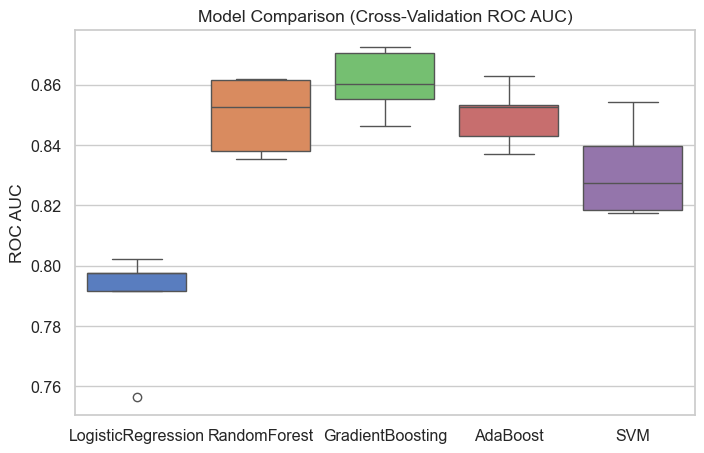

In [156]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[result[m] for m in list(result.keys())])
plt.xticks(range(len(result)), result.keys())
plt.ylabel('ROC AUC')
plt.title('Model Comparison (Cross-Validation ROC AUC)')
plt.show()

# Fit best model on full train set and evaluate test set
### Select best model by mean CV AUC above and evaluate standard metrics on the test set

In [158]:
best_name = max(result.keys(), key=lambda k: result[k].mean())
best_name, result[best_name].mean()

('GradientBoosting', np.float64(0.8609364857787613))

Test Accuracy:  0.8645
Test Precision:  0.7276
Test Recall:  0.4962
Test F1-Score:  0.5900
Test ROC AUC:  0.8705

Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1607
           1       0.73      0.50      0.59       393

    accuracy                           0.86      2000
   macro avg       0.81      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000



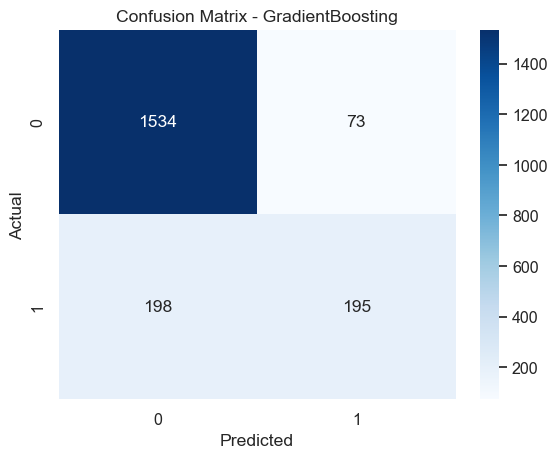

In [159]:
best_model = models[best_name]
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier',best_model)])
best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

#metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc: .4f}")
print(f"Test Precision: {prec: .4f}")
print(f"Test Recall: {rec: .4f}")
print(f"Test F1-Score: {f1: .4f}")
print(f"Test ROC AUC: {roc: .4f}")

print("\nClassification Report: ")
print(classification_report(y_test, y_pred))

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

# Feature Importance (If applicable)
#### If the choosen model support feature importance (RandomForest/GradientBoosting), show top features

age                     0.323152
products_number         0.270591
active_member_0         0.082541
balance_per_product     0.063884
balance                 0.055931
country_Germany         0.044624
estimated_salary        0.031151
salary_balance_ratio    0.026472
credit_score            0.026169
active_member_1         0.023327
age_group_45-54         0.016049
gender_Female           0.007748
age_group_55-64         0.006400
tenure                  0.006198
gender_Male             0.005510
age_group_65+           0.003636
country_France          0.002574
country_Spain           0.001157
age_group_35-44         0.000891
credit_card_1           0.000559
dtype: float64

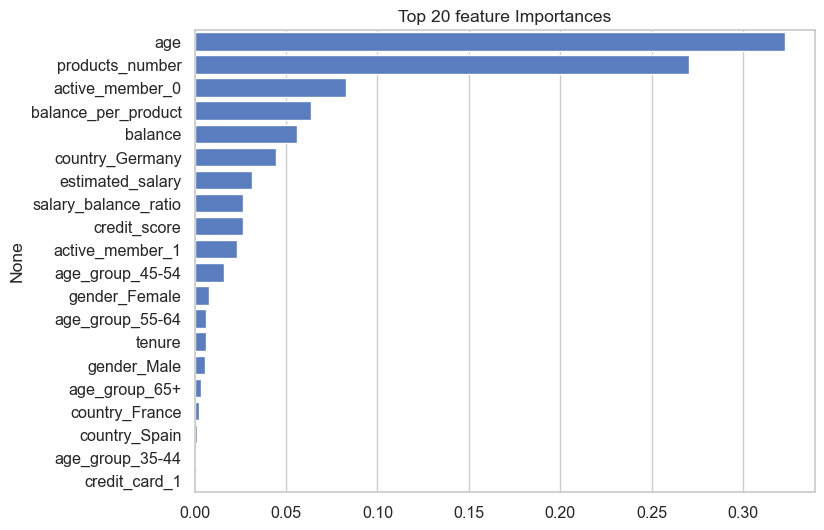

In [162]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    num_fest = numeric_features
    cat_feats = list(best_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
    features_name = num_fest + cat_feats
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    f1 = pd.Series(importances, index=features_name).sort_values(ascending=False)[:20]
    display(f1)
    plt.figure(figsize=(8,6))
    sns.barplot(x=f1.values, y=f1.index)
    plt.title('Top 20 feature Importances')
    plt.show()
else:
    print('Selected model does not provide feature_importance_attribute.')

## Save the best pipeline and preprocessing artifacts

In [165]:
import joblib

joblib.dump(best_pipeline, "best_churn_pipeline.pkl")

print("Model pipeline saved successfully!")

Model pipeline saved successfully!
